In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("spotify_top_1000_tracks.csv")
df.head()

,track_name,artist,album,release_date,popularity,spotify_url,id,duration_min
0,All The Stars (with SZA),Kendrick Lamar,Black Panther The Album Music From And Inspire...,2018-02-09,95,https://open.spotify.com/track/3GCdLUSnKSMJhs4...,3GCdLUSnKSMJhs4Tj6CV3s,3.869767
1,Starboy,The Weeknd,Starboy,2016-11-25,90,https://open.spotify.com/track/7MXVkk9YMctZqd1...,7MXVkk9YMctZqd1Srtv4MB,3.840883
2,Señorita,Shawn Mendes,Señorita,2019-06-21,80,https://open.spotify.com/track/0TK2YIli7K1leLo...,0TK2YIli7K1leLovkQiNik,3.182667
3,Heat Waves,Glass Animals,Dreamland,2020-08-07,87,https://open.spotify.com/track/3USxtqRwSYz57Ew...,3USxtqRwSYz57Ewm6wWRMp,3.980083
4,Let Me Love You,DJ Snake,Encore,2016-08-05,87,https://open.spotify.com/track/0lYBSQXN6rCTvUZ...,0lYBSQXN6rCTvUZvg9S0lU,3.432433


In [16]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()

df = df.drop_duplicates(subset=['track_name', 'artist'])

df.head()

,track_name,artist,album,release_date,popularity,spotify_url,id,duration_min,year
0,All The Stars (with SZA),Kendrick Lamar,Black Panther The Album Music From And Inspire...,2018-02-09,95,https://open.spotify.com/track/3GCdLUSnKSMJhs4...,3GCdLUSnKSMJhs4Tj6CV3s,3.869767,2018.0
1,Starboy,The Weeknd,Starboy,2016-11-25,90,https://open.spotify.com/track/7MXVkk9YMctZqd1...,7MXVkk9YMctZqd1Srtv4MB,3.840883,2016.0
2,Señorita,Shawn Mendes,Señorita,2019-06-21,80,https://open.spotify.com/track/0TK2YIli7K1leLo...,0TK2YIli7K1leLovkQiNik,3.182667,2019.0
3,Heat Waves,Glass Animals,Dreamland,2020-08-07,87,https://open.spotify.com/track/3USxtqRwSYz57Ew...,3USxtqRwSYz57Ewm6wWRMp,3.980083,2020.0
4,Let Me Love You,DJ Snake,Encore,2016-08-05,87,https://open.spotify.com/track/0lYBSQXN6rCTvUZ...,0lYBSQXN6rCTvUZvg9S0lU,3.432433,2016.0


In [17]:
if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut(
        df['tempo'],
        bins=[0, 100, 140, np.inf],
        labels=['Slow', 'Medium', 'Fast']
    )

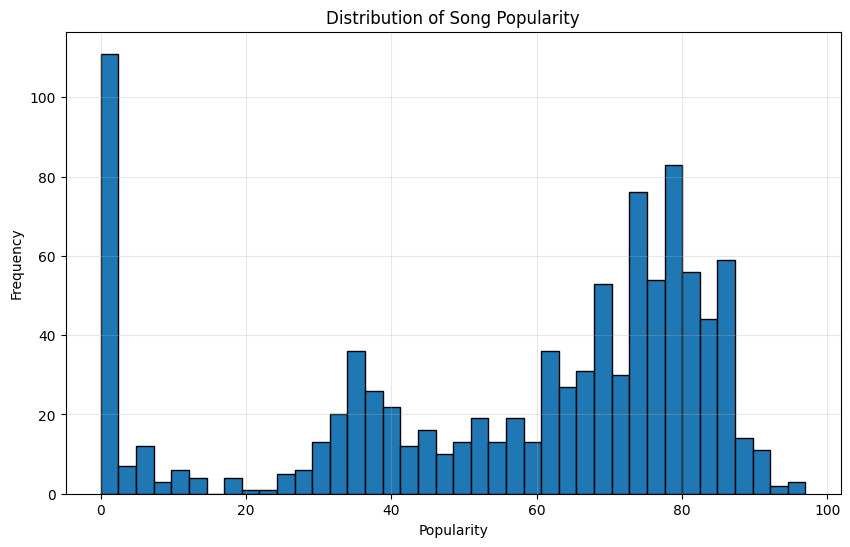

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df['popularity'], bins=40, edgecolor='black')

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.show()

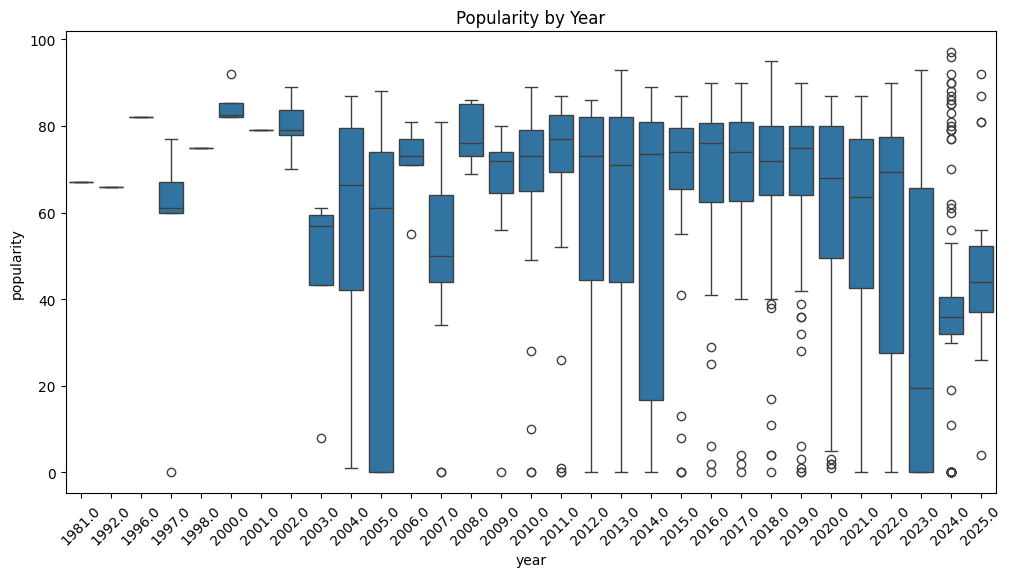

In [10]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(x='year', y='popularity', data=df)

plt.title("Popularity by Year")
plt.xticks(rotation=45)

plt.show()

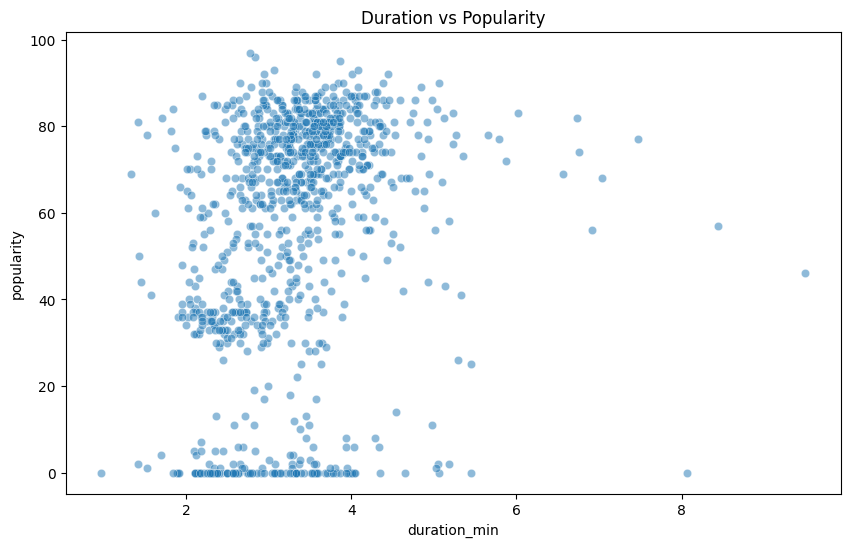

In [ ]:
plt.figure(figsize=(10,6))

sns.pairplot(df[['duration_min', 'popularity', 'year']].dropna())

plt.title("Duration vs Popularity")
plt.show()

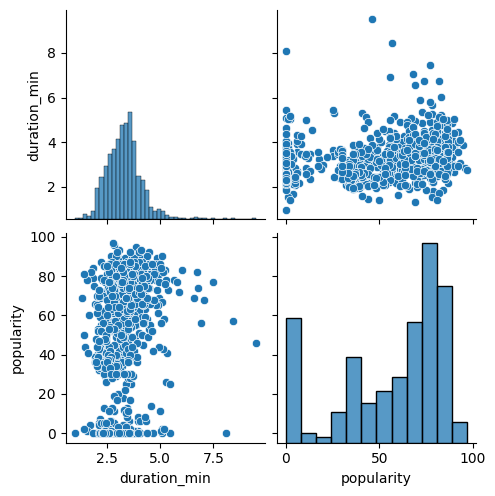

In [12]:
sns.pairplot(df[['duration_min', 'popularity']].dropna())
plt.show()

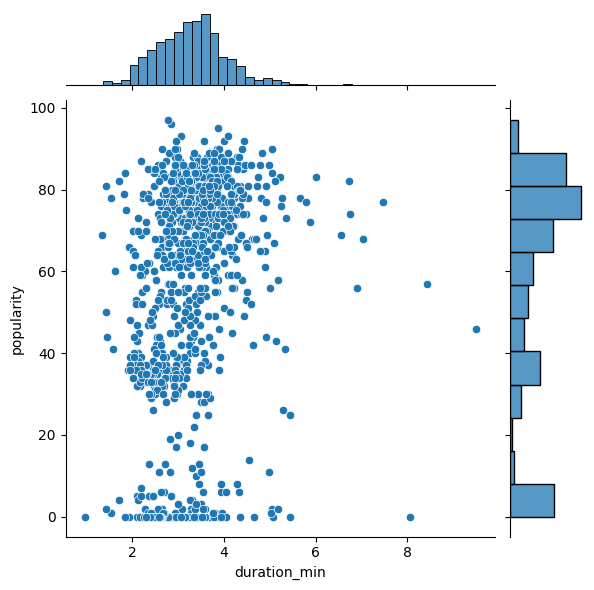

In [13]:
sns.jointplot(x='duration_min', y='popularity', data=df, kind='scatter')
plt.show()

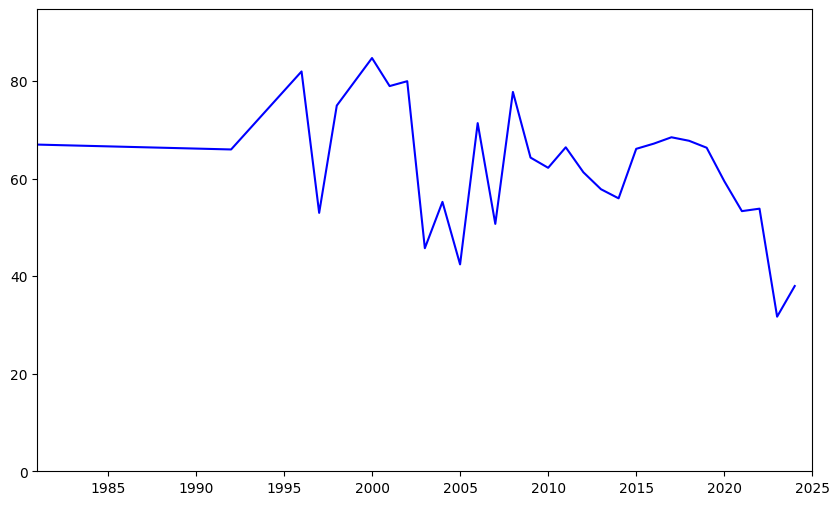

In [14]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

yearly = df.groupby('year')['popularity'].mean().reset_index()
yearly = yearly.sort_values('year')

fig, ax = plt.subplots(figsize=(10,6))

ax.set_xlim(yearly['year'].min(), yearly['year'].max())
ax.set_ylim(0, yearly['popularity'].max() + 10)

line, = ax.plot([], [], color='blue')

def update(i):
    x = yearly['year'][:i]
    y = yearly['popularity'][:i]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, update, frames=len(yearly), interval=100)

ani.save("popularity_trend.gif", writer=PillowWriter(fps=10))

plt.show()